Luzar Dwain Ruszardi

Program Studi Sains data

Universitas Brawijaya

## **Perintah**
1. Buatlah agentic AI yang memiliki tool RAG (dapat juga ditambahkan tool lain lagi)

## **Ketentuan Hasil**
1. Lakukan ingesting ke vector database dengan model embedding yang anda miliki
2. Jumlah data yang dimasukkan menyesuaikan dengan rate limit model embedding yang dimiliki. Tidak perlu keseluruhan data.
3. Tanyakan agent dengan pertanyaan yang ada di database tersebut. Hasil jawaban agent harus merujuk pada referensi RAG nya.
4. Dataset bebas (cantumkan link dataset dalam file laporan .ipynb atau dalam google form)

### **1. Install Dependency**

In [ ]:
%pip install -q \
google-play-scraper \
pandas \
numpy \
sqlalchemy \
psycopg2-binary \
faiss-cpu \
sentence-transformers \
langchain \
langchain-community \
langchain-core \
langchain-google-genai \
langgraph \
tqdm \
unidecode

Note: you may need to restart the kernel to use updated packages.


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


### **2. Data Collection**

In [ ]:
from datetime import datetime
from google_play_scraper import reviews, Sort

app_id = "com.shopee.id"
today = datetime.today()
batas = datetime(today.year, today.month, 1) # untuk dapat review dari tanggal 1 bulan ini sampai sekarang

# inisialisasi seluruh review
all_reviews = []
# penanda posisi terakhir data yang sudah diambil
token = []

while True:
  results, token = reviews(
      app_id,
      lang="id",
      country="id",
      sort = Sort.NEWEST,
      count = 200
      continuation_token = token
  )

  if not results:
    break

  for review in results:
    if review["at"] < batas:
      break
    all_reviews.append(review)

  if results[-1]["at"] < batas:
    break

print("Jumlah review: ", len(all_reviews))


Jumlah review:  22214


In [ ]:
import pandas as pd
df = pd.DataFrame(all_reviews)
print(df.columns.tolist())

['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


In [ ]:
df = df[
    [
        "reviewId",
        "userName",
        "content",
        "score",
        "at",
        "replyContent",
        "repliedAt"
    ]
]
df.head(5)

,reviewId,userName,content,score,at,replyContent,repliedAt
0,62b04d55-fb4e-4e80-915a-e492659f653e,Rendy Ajja,suka banget pake shopee tapi KLO itu suka kece...,5,2026-05-29 15:08:26,"Hai kak Rendy Ajja , thanks ya bintang dan ula...",2026-05-29 16:26:03
1,0ad4b68f-55dc-43c3-b1cc-37086f3e4af7,Abdul Rohman,bagus sekali akusuka shoper,5,2026-05-29 15:08:26,"Hi kak Abdul Rohman, wahh makasih buat bintang...",2026-05-29 16:25:25
2,dd5ea715-4a85-48ca-bef8-b241fdd0a28b,Billique Studio,"Mantap, terpecaya sejak dulu, top lahh sudah l...",5,2026-05-29 15:08:26,Haii kak mimin seneng banget nih kakak udah ka...,2024-06-28 14:17:27
3,0af54d9a-5e24-4a83-9486-68e3b6493348,Ismail Hubura,semoga kedepannya lebih baik lagi,5,2026-05-29 15:05:35,"Hi Kak Ismail Hubura, makasih bgt ya review da...",2026-05-29 16:25:12
4,27c8cf8e-469d-4fe1-9725-c008c8597516,Sarip Hidayat,sy sangat puas dengan aplikasi shopee mudah da...,5,2026-05-29 15:05:08,"Haii kak Sarip Hidayat , maacih yaa buat revie...",2026-05-29 16:24:10


In [ ]:
df.to_csv("Review Shopee Bulan Mei 2026.csv", index=False)

### **3. Data Preparation**

In [ ]:
from unidecode import unidecode
import re

In [ ]:
df_clean = df.copy()

def clean_text(text):
  text = str(text)
  text = unidecode(text)
  text = re.sub(r"\s+", " ", text) # menghapus spasi berlebih
  text = text.strip() # menghapus spasi di awal dan akhir
  return text

df_clean["content"] = df_clean["content"].apply(clean_text)

# menghapus duplikasi data
df_clean.drop_duplicates(
    subset = ["content"],
    inplace = True # mengubah dataframe secara langsung
)

# menghapus review yang terlalu pendek
df_clean = df_clean[
    df_clean["content"].str.len() > 10
]

# mereset index
df_clean.reset_index(
    drop = True,
    inplace = True
)

# mengganti NaT menjadi None pada kolom repliedAt
df_clean["repliedAt"] = df_clean["repliedAt"].astype(object)
df_clean["repliedAt"] = df_clean["repliedAt"].where(
    pd.notnull(df_clean["repliedAt"]),
    None
)

# menangani jika terdapat replyContent yang kosong
df_clean["replyContent"] = df_clean["replyContent"].where(
    pd.notnull(df_clean["replyContent"]),
    None
)

### **4. Membuat Database**

#### **4.1 Buat Koneksi ke PostgreSQL**

In [ ]:
import psycopg2
from getpass import getpass

password = getpass("Masukkan password PostgreSQL: ")

try:
  conn = psycopg2.connect(
      host = "127.0.0.1",
      port = "5432",
      user = "postgres",
      password = password,
  )
  conn.autocommit = True
  cursor = conn.cursor()
  print("Koneksi ke PostgreSQL berhasil: ")

  cursor.execute("create database shopee_reviews_langchain_celerates_db")
  print("Database berhasil dibuat")

except Exception as e:
  print(f"Terjadi error: {e}")

#### **4.2 Buat Koneksi ke Database**

In [ ]:
import psycopg2
from getpass import getpass

password = getpass("Masukkan password PostgreSQL: ")

conn = psycopg2.connect(
    host = "localhost",
    port = "5432",
    user = "postgres",
    password = password,
    dbname = "shopee_reviews_langchain_celerates_db"
)

cursor = conn.cursor()
print("Berhasil connect")


Berhasil connect


In [ ]:
df_clean.columns

Index(['reviewId', 'userName', 'content', 'score', 'at', 'replyContent',
       'repliedAt'],
      dtype='object')

#### **4.3 Buat Tabel di Database**

In [ ]:
conn.rollback()

In [ ]:
cursor.execute("""
create table if not exists shopee_reviews (
               review_id serial primary key,
               review_unique_id text unique not null,
               username text not null,
               review_text text not null,
               rating integer not null check (rating >=1 and rating <= 5),
               review_date timestamp,
               reply_text text,
               reply_date timestamp
               );
""")

In [ ]:
data = [
    (
        row.reviewId,
        row.userName,
        row.content,
        row.score,
        row.at,
        row.replyContent,
        row.repliedAt
    )
    # itertuples berfungsi untuk menghasilkan tuple, sedangkan false agar index tidak dimasukkan ke tuple
    for row in df_clean.itertuples(index=False)
]

cursor.executemany("""
    insert into shopee_reviews (
                   review_unique_id,
                   username,
                   review_text,
                   rating,
                   review_date,
                   reply_text,
                   reply_date
                   )
    values (%s, %s, %s, %s, %s, %s, %s)
    on conflict (review_unique_id) do nothing
""", data)

# Note:
# on conflict (review_unique_id) do nothing digunakan kalau data yang ingin dimasukkan
# melanggar constraint tertentu, maka tidak akan error, melainkan akan diabaikan baris tersebut
conn.commit()

### **5. RAG Indexing**

#### **5.1 Ambil Data dari Database**

In [ ]:
df_db = pd.read_sql(
    "select * from shopee_reviews",
    conn
)
df_db.head()

,review_id,review_unique_id,username,review_text,rating,review_date,reply_text,reply_date
0,1,62b04d55-fb4e-4e80-915a-e492659f653e,Rendy Ajja,suka banget pake shopee tapi KLO itu suka kece...,5,2026-05-29 15:08:26,"Hai kak Rendy Ajja , thanks ya bintang dan ula...",2026-05-29 16:26:03
1,2,0ad4b68f-55dc-43c3-b1cc-37086f3e4af7,Abdul Rohman,bagus sekali akusuka shoper,5,2026-05-29 15:08:26,"Hi kak Abdul Rohman, wahh makasih buat bintang...",2026-05-29 16:25:25
2,3,dd5ea715-4a85-48ca-bef8-b241fdd0a28b,Billique Studio,"Mantap, terpecaya sejak dulu, top lahh sudah l...",5,2026-05-29 15:08:26,Haii kak mimin seneng banget nih kakak udah ka...,2024-06-28 14:17:27
3,4,0af54d9a-5e24-4a83-9486-68e3b6493348,Ismail Hubura,semoga kedepannya lebih baik lagi,5,2026-05-29 15:05:35,"Hi Kak Ismail Hubura, makasih bgt ya review da...",2026-05-29 16:25:12
4,5,27c8cf8e-469d-4fe1-9725-c008c8597516,Sarip Hidayat,sy sangat puas dengan aplikasi shopee mudah da...,5,2026-05-29 15:05:08,"Haii kak Sarip Hidayat , maacih yaa buat revie...",2026-05-29 16:24:10


#### **5.2 Membuat LangChain Document**

In [ ]:
from langchain_core.documents import Document

# dokumen adalah format standar langchain untuk menyimpan teks dan metadata
documents = []

# for untuk mengiterasi setiap baris pada dataframe df_db
# _ sebenarnya sama saja dengan "index"
# iterrows untuk mengembalikan index dan row untuk setiap baris
for _, row in df_db.iterrows():
  doc = Document(
      page_content = row["review_rext"],
      metadata = {
          "review_id:" row["review_id"],
          "username": row["usermame"],
          "rating": int(row["rating"]),
          "review_date": str(row["review_date"]),
          "reply_text": row["reply_text"] if pd.notna(row["reply_text"]) else None,
          "reply_date": str(row["reply_date"] if pd.notna(row["reply_date"]) else None)
      }
  )
  documents.append(doc)
print("Total Documents: ", len(documents))


Total Documents: 16175


### **5.3 Embedding Model**

In [ ]:
from langchain_community.embeddings import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

# contoh
vector = embedding_model.embed_query(
    "Shopee sering error"
)
print(len(vector))

C:\Users\Luzar Dwain Ruszardi\AppData\Local\Temp\ipykernel_23520\1436205839.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


384


#### **5.4 Membuat FAISS Vector Database**

In [ ]:
from langchain_community.vectorstores import FAISS

vectorstore = FAISS.from_documents(
    documents,
    embedding_model
)

In [ ]:
# save vector database
vectorstore.save_local(
    "shopee_faiss_index"
)

In [1]:
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

vectorstore = FAISS.load_local(
    "shopee_faiss_index",
    embeddings,
    allow_dangerous_deserialization=True
)

C:\Users\Luzar Dwain Ruszardi\AppData\Local\Temp\ipykernel_17824\1382551391.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings
c:\Users\Luzar Dwain Ruszardi\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\utils\pydantic.py:41: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1
C:\Users\Luzar Dwain Ruszardi\AppData\Local\Temp\ipykernel_17824\1382551391.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `lang

#### **5.5 Membuat Retriever**

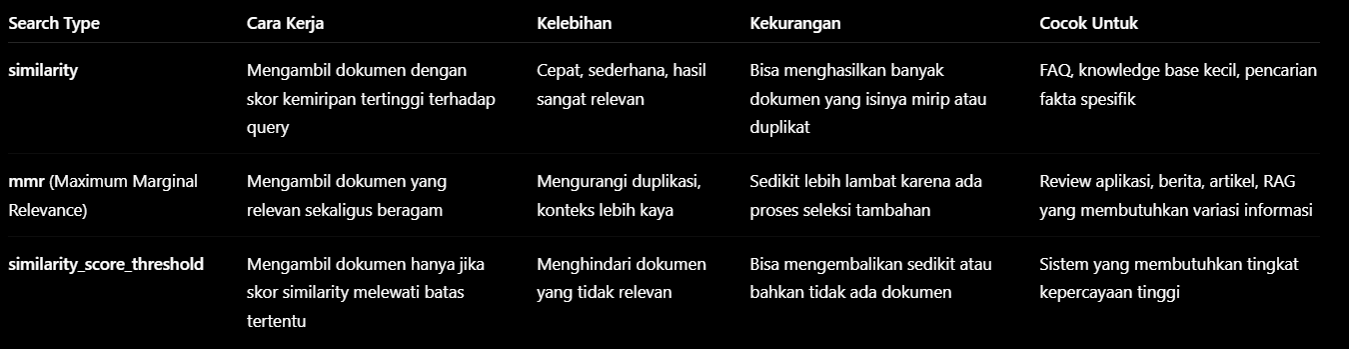

In [ ]:
retriever = vectorstore.as_retriever(
    search_type = "mmr",
    search_kwargs = {
        # setiap kali user bertanya, maka akan diambil sebanyak 50 review yang paling terkait dengan pertanyaan tersebut.
        # Hal ini disebabkan jika mengambil seluruh review (20 ribu review) maka akan menyebabkan proses generativ yang dilakukan oleh
        # AI nantinya menjadi tidak efisien karena menghabiskan banyak token serta memakan banyak waktu executions.
        "k": 50, # jumlah review akhir setelah proses mmr
        "fetch_k": 100, # jumlah review awal yang diambil sebelum proses mmr
        "lambda_mult": 0.5 # keseimbangan antara relevansi dan keberagaman (0=sangat beragam, 1=sangat relevan)
    }
)

# contoh
reviews = retriever.invoke(
    "keluhan pengguna pada driver"
)
for review in reviews:
  print(review.page_content)
  print("=" * 50)

kirim instant ga dpt driver pesen makan ga dpt driver complain ke cs cuma bilang salah driver cuma kirim laporan doang tp ga ada tindakan apa2 dri shoppe nya makin mengecewakan rugi waktu saya pake aplikasi ini
perusahaan zhalim terhadap Mitra driver dan pekerja lapangan lainnya
driver2 bejat pecatin semua hey GOBLOKK
saran, kasih pilihan driver favorit biar ga salah pilih driver sedangkan di aplikasi driver aja ada rating customer biar driver tau itu customer baik apa ga
aplikasi tidak manusiawi ke driver
akun tiba' dibatasin gabisa co samsek, Uda kirim keluhan belum diproses' dri kemaren
error truk yang di maps nya
layanan kurir sangat buruk dan siapa aja jangan pesan di sini
pengalaman buruk cari driver lambat tutup aja aplikasinya
hilangkan fitur cod, jadi banyak orderan fiktif merugikan driver
Saya kecewa berat dengan driver Shopeefood yang kebanyakan tidak jujur dan tidak bertanggung jawab atas tindakan dan pesanan yang diantar dengan keadaan yang sangat buruk tumpah dan berserak

In [ ]:
retriever = vectorstore.as_retriever(
    search_type = "mmr",
    search_kwargs = {
        # setiap kali user bertanya, maka akan diambil sebanyak 50 review yang paling terkait dengan pertanyaan tersebut.
        # Hal ini disebabkan jika mengambil seluruh review (20 ribu review) maka akan menyebabkan proses generativ yang dilakukan oleh
        # AI nantinya menjadi tidak efisien karena menghabiskan banyak token serta memakan banyak waktu executions.
        "k": 50, # jumlah review akhir setelah proses mmr
        "fetch_k": 100, # jumlah review awal yang diambil sebelum proses mmr
        "lambda_mult": 0.5 # keseimbangan antara relevansi dan keberagaman (0=sangat beragam, 1=sangat relevan)
    }
)

# contoh
reviews = retriever.invoke(
    "keluhan pengguna pada driver"
)
for review in reviews:
  print(review.page_content)
  print("=" * 50)


kirim instant ga dpt driver pesen makan ga dpt driver complain ke cs cuma bilang salah driver cuma kirim laporan doang tp ga ada tindakan apa2 dri shoppe nya makin mengecewakan rugi waktu saya pake aplikasi ini
perusahaan zhalim terhadap Mitra driver dan pekerja lapangan lainnya
driver2 bejat pecatin semua hey GOBLOKK
saran, kasih pilihan driver favorit biar ga salah pilih driver sedangkan di aplikasi driver aja ada rating customer biar driver tau itu customer baik apa ga
aplikasi tidak manusiawi ke driver
akun tiba' dibatasin gabisa co samsek, Uda kirim keluhan belum diproses' dri kemaren
error truk yang di maps nya
layanan kurir sangat buruk dan siapa aja jangan pesan di sini
pengalaman buruk cari driver lambat tutup aja aplikasinya
hilangkan fitur cod, jadi banyak orderan fiktif merugikan driver
Saya kecewa berat dengan driver Shopeefood yang kebanyakan tidak jujur dan tidak bertanggung jawab atas tindakan dan pesanan yang diantar dengan keadaan yang sangat buruk tumpah dan berserak

### **6. Tools**

#### **6.1 Tool Retrieved Reviews**

In [ ]:
from langchain_core.tools import tool

In [ ]:
@tool
def retrieve_reviews(question: str):
    """
    Retrieve Shopee reviews dari FAISS
    """

    docs = retriever.invoke(question)

    results = []

    for doc in docs:
        results.append(
            f"""
            Review ID: {doc.metadata.get("review_id")}
            Rating: {doc.metadata.get("rating")}
            Review: {doc.page_content}
            Review Date: {doc.metadata.get("review_date")}
            Reply: {doc.metadata.get("reply_text") if doc.metadata.get("reply_text") else "Tidak ada balasan"}
            Reply Date: {doc.metadata.get("reply_date") if doc.metadata.get("reply_date") else "Tidak ada tanggal balasan"}
            """
        )

    return "\n\n".join(results)

#### **6.2 Koneksi ke Gemini**

In [ ]:
# Koneksi ke Gemini
from langchain_google_genai import GoogleGenerativeAI
from getpass import getpass

api_key = getpass("Masukkan API Key Gemini: ")

try:
  llm = GoogleGenerativeAI(
      model = "gemini-2.5-flash-lite",
      google_api_key = api_key
  )
  response = llm.invoke("Hello, world!")
  print("Koneksi ke Gemini berhasil")
  print(response)
except Exception as e:
  print("Koneksi ke Gemini gagal")
  print(e)

Koneksi ke Gemini berhasil
Hello there! It's nice to meet you. How can I help you today?


#### **6.3 Tool Sentiment Analysis**

In [ ]:
@tool
def analyze_sentiment(review:str) -> str:
    """
    Analyze sentiment of review.
    """

    prompt = f"""
            Analyze the sentiment.

            Categories:
            - Positive
            - Neutral
            - Negative

            Review:
            {review}
            """
    response = llm.invoke(prompt)
    return response

#### **6.4 Tool Statistik**

In [ ]:
@tool
def review_statistics():
    """Generate statistics of reviews in database.
    """
    return {
        "total_reviews": len(df_clean),
        "avg_rating": float(df_clean["score"].mean()),
        "rating_1": int((df_clean["score"] == 1).sum()),
        "rating_2": int((df_clean["score"] == 2).sum()),
        "rating_3": int((df_clean["score"] == 3).sum()),
        "rating_4": int((df_clean["score"] == 4).sum()),
        "rating_5": int((df_clean["score"] == 5).sum())
    }

### **7. LangGraph Agent**

#### **7.1 Membuat State**

In [ ]:
# typedDict untuk mendefinisikan struktur dictionary yg memiliki key tertentu beserta tipe datanya

# sequence adalah tipe untuk data yg berurutan. Pada kode di bawah, messages berisi kumpulan data berurutan, yakni list chat messages
# yang berupa HumanMessage("Halo"),
#             AIMessage("Hai")

# annotated digunakan untuk menambahkan metadata pada tipe data. Pada kode di bawah, metadata yang ditambahkan adalah fungsi add_messages,
# yang digunakan untuk menambahkan pesan ke dalam graph state.
# Jadi, messages adalah sequence, dan ketika state diperbarui, fungsi add messages akan menggabungkan nilainya.
# Fungsinya adalah untuk menggabungkan pesan baru dengan pesan yang sudah ada sebelumnya dalam graph state.
# Tanpa add messages, pesan lama akan hilang
from typing import TypedDict, Annotated, Sequence
from langgraph.graph.message import add_messages

class agentstate(TypedDict):
    messages: Annotated[
        Sequence,
        add_messages
    ]

    task_type: str

    retrieved_docs: str

    sentiment_result: str

    statistics_result: str

    final_answer: str

#### **7.2 Router Node**

In [ ]:
from typing import Literal

def router_node(
    state: agentstate
) -> Literal[
    "general_chat",
    "retrieval"
]:

    question = state["messages"][-1].content.lower()

    review_keywords = [
        "review",
        "ulasan",
        "keluhan",
        "pengguna",
        "rating",
        "shopeefood",
        "voucher",
        "checkout",
        "kurir",
        "pengiriman",
        "sentimen",
        "sentiment",
        "statistik"
    ]

    if any(
        keyword in question
        for keyword in review_keywords
    ):
        return "retrieval"

    return "general_chat"

#### **7.3 General Chat Node**

In [ ]:
def general_chat_node(state: agentstate):
  user_question = state["messages"][-1]

  prompt = f"""
          Kamu adalah Shopee Review Analysis Agent yang membantu menjawab pertanyaan terkait aplikasi Shopee berdasarkan data review pengguna.

          Jawablah pertanyaan berikut dengan singkat dan jelas:
          {user_question}
          """
  response = llm.invoke(prompt)
  return {
      "final_answer": response
  }

#### **7.4 Retrieval Node**

In [ ]:
def retrieval_node(state):

    question = state["messages"][-1].content.lower()

    retrieved_docs = retrieve_reviews.invoke(question)

    task_type = "retrieval"

    if any(
        word in question
        for word in [
            "sentimen",
            "sentiment",
            "positif",
            "negatif"
        ]
    ):
        task_type = "sentiment"

    elif any(
        word in question
        for word in [
            "statistik",
            "jumlah review",
            "rating rata-rata",
            "average rating"
        ]
    ):
        task_type = "statistics"

    return {
        "retrieved_docs": retrieved_docs,
        "task_type": task_type
    }

#### **7.5 Retrieval Router**

In [ ]:
from typing import Literal

def retrieval_router(
    state: agentstate
) -> Literal[
    "sentiment",
    "statistics",
    "reasoning"
]:

    task = state["task_type"]

    if task == "sentiment":
        return "sentiment"

    if task == "statistics":
        return "statistics"

    return "reasoning"

#### **7.6 Sentiment Node**

In [ ]:
def sentiment_node(state):
    docs = state["retrieved_docs"]
    sentiment = analyze_sentiment.invoke(
        docs
    )
    return {
        "sentiment_result": sentiment
    }

#### **7.7 Statistics Node**

In [ ]:
def statistics_node(state):
    docs = state["retrieved_docs"]
    stats = review_statistics.invoke(
        docs
    )
    return {
        "statistics_result": stats
    }

#### **7.8 Reasoning Node**

In [ ]:
def reasoning_node(state):

    last_message = state["messages"][-1]

    if hasattr(last_message, "content"):
        question = last_message.content
    else:
        question = str(last_message)

    docs = state.get(
        "retrieved_docs",
        ""
    )

    sentiment = state.get(
        "sentiment_result",
        ""
    )

    stats = state.get(
        "statistics_result",
        ""
    )

    prompt = f"""
    Anda adalah analis review Shopee.

    Pertanyaan:
    {question}

    Review yang ditemukan:
    {docs}

    Hasil Analisis Sentimen:
    {sentiment}

    Statistik Review:
    {stats}

    Instruksi:
    1. Analisis seluruh review yang ditemukan.
    2. Cari pola atau masalah yang berulang.
    3. Berikan ringkasan umum.
    4. Gunakan minimal 3 referensi review jika tersedia.
    5. Jangan hanya fokus pada satu review.
    6. Jika terdapat tren dominan, jelaskan.
    7. Jawab menggunakan bahasa yang sama dengan bahasa pengguna.

    Jawaban:
    """

    response = llm.invoke(prompt)

    if hasattr(response, "content"):
        answer = response.content
    else:
        answer = str(response)

    return {
        "final_answer": answer
    }

#### **7.9 Membuat Graph**

In [ ]:
from langgraph.graph import StateGraph, START, END

from langchain_core.messages import (
    HumanMessage,
    AIMessage
)

In [ ]:
from langgraph.graph import StateGraph

graph = state_graph = StateGraph(
    agentstate
)

graph.add_node("general_chat", general_chat_node)
graph.add_node("retrieval", retrieval_node)
graph.add_node("sentiment", sentiment_node)
graph.add_node("statistics", statistics_node)
graph.add_node("reasoning", reasoning_node)

graph.add_conditional_edges(
    START,
    router_node,
    {
        "general_chat": "general_chat",
        "retrieval": "retrieval",
    }
)

graph.add_conditional_edges(
    "retrieval",
    retrieval_router,
    {
        "sentiment": "sentiment",
        "statistics": "statistics",
        "reasoning": "reasoning"
    }
)

graph.add_edge("statistics", "reasoning")
graph.add_edge("sentiment", "reasoning")
graph.add_edge("general_chat", END)
graph.add_edge("reasoning", END)

In [ ]:
app = graph.compile()
print(app)

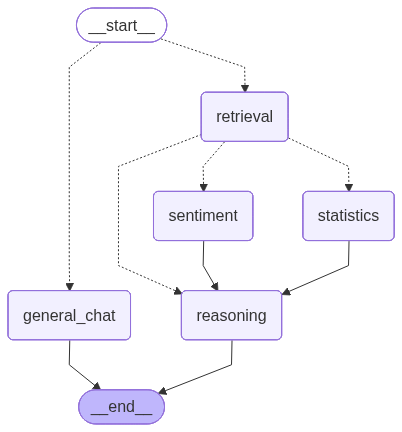

In [ ]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

### **8. Uji Coba**

In [ ]:
conversation_history = []

#### **8.1 Pengujian Kemampuan Sistem dalam Mengidentifikasi Keluhan dan Sentimen Berdasarkan Topik Spesifik**

In [ ]:
while True:
    user_input = input(
        "\nUser: "
    )

    print(f"\nUser: {user_input}")

    if user_input.lower() == "exit" or user_input.lower() == "keluar":
        print("Terima kasih telah menggunakan Shopee Review Analysis Agent. Sampai jumpa!")
        break

    conversation_history.append(
        HumanMessage(content=user_input)
    )

    result = app.invoke(
        {
            "messages": conversation_history
        }
    )

    answer = result["final_answer"]

    conversation_history.append(AIMessage(content=answer)
    )

    print(f"Shopee Assistant: {answer}")


User: Hai, selamat siang, apa saja alasan pengguna memberikan rating 1 pada review di play store?
Shopee Assistant: Tentu, sebagai analis review Shopee, saya akan menganalisis review yang Anda berikan untuk mengidentifikasi alasan pengguna memberikan rating 1.

Berdasarkan review yang ditemukan, berikut adalah beberapa alasan utama pengguna memberikan rating 1 pada aplikasi Shopee:

**1. Gangguan Iklan yang Berlebihan:**
Salah satu keluhan paling dominan adalah mengenai iklan yang muncul terlalu sering dan mengganggu aktivitas pengguna. Pengguna merasa iklan tersebut muncul di berbagai tempat, termasuk saat bermain game, menonton video, atau bahkan saat sedang membaca.

*   **Referensi Review:**
    *   **Review ID: 15100:** "saya pengguna apk Shopee dan sering berbelanja dengan senang si shoppe... tapi yang membuat kesal iklan Shopee ini muncul dmna-mana sehingga mnjadi mengganggu! itulah alasan saya kenapa sya memberi rating bintang satu..."
    *   **Review ID: 2183:** "Jelek Gangg

#### **8.2 Pengujian Kemampuan Sistem dalam Menghasilkan Insight dan Rekomendasi Berdasarkan Data Ulasan Pengguna**

In [ ]:
while True:
    user_input = input(
        "\nUser: "
    )

    print(f"\nUser: {user_input}")

    if user_input.lower() == "exit" or user_input.lower() == "keluar":
        print("Terima kasih telah menggunakan Shopee Review Analysis Agent. Sampai jumpa!")
        break

    conversation_history.append(
        HumanMessage(content=user_input)
    )

    result = app.invoke(
        {
            "messages": conversation_history
        }
    )

    answer = result["final_answer"]

    conversation_history.append(AIMessage(content=answer)
    )

    print(f"Shopee Assistant: {answer}")


User: apakah distribusi rating menunjukkan bahwa pengguna cenderugn puas atau tidak puas?
Shopee Assistant: Berdasarkan analisis terhadap seluruh review yang ditemukan, dapat disimpulkan bahwa **pengguna cenderung memiliki sentimen yang beragam, namun terdapat kecenderungan yang kuat ke arah ketidakpuasan jika dilihat dari distribusinya**.

Berikut adalah rincian analisisnya:

**Distribusi Rating:**
Dari data yang tersedia, terlihat bahwa rating 1 dan 5 mendominasi, namun rating 1 memiliki jumlah yang signifikan. Terdapat banyak keluhan yang berujung pada rating rendah, sementara rating tinggi seringkali disertai dengan catatan atau harapan untuk perbaikan.

**Pola atau Masalah yang Berulang:**

*   **Masalah Pengiriman dan Kurir:** Keluhan mengenai pengiriman yang terlambat, kurir yang tidak ramah, atau ketidaksesuaian estimasi pengiriman sangat sering muncul. Contohnya pada Review ID: 14782 yang menyatakan "terlalu mengecewakan pengirim tidak sesuai estimasi yang di tentukan" dan Re